# Regime Detection Notebook

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from regime_detection.data.ingestion import get_merged_df
from regime_detection.features.features import feature_pipeline
from regime_detection.models.stationarity import stationarity_pipeline


## Config

In [6]:
seed = 42

In [7]:
df_raw = get_merged_df()

df_features = feature_pipeline(df_raw)

split_ratio = .8
split_index = int(len(df_features) * split_ratio)

df_train , df_test = df_features.iloc[:split_index, :], df_features.iloc[split_index:, :]

df_test.head()

Computing log returns...
Computing week-on-week changes...
Computing lagged values...
Computing rolling returns volatility...
Computing commodity-to-commodity differences...
Computing rolling window z-scores...


,RBRTE,RWTC,T10Y2Y,VIXCLS,DTWEXBGS,WCESTUS1,RNGWHHD,days_since_opec,days_since_fomc,RBRTE_log_return,...,RBRTE_log_return_12_returns_rol_vol,RWTC_log_return_4_returns_rol_vol,RWTC_log_return_12_returns_rol_vol,RNGWHHD_log_return_4_returns_rol_vol,RNGWHHD_log_return_12_returns_rol_vol,RBRTE_RWTC_diff,RBRTE_log_return_rol_z_score,RWTC_log_return_rol_z_score,RNGWHHD_log_return_rol_z_score,RBRTE_RWTC_diff_rol_z_score
period,,,,,,,,,,,,,,,,,,,,,
2022-06-24,116.83,107.88,0.09,27.23,120.4853,415566,6.43,205.0,9,-0.068234,...,0.045741,0.052331,0.040652,0.111358,0.110095,8.95,-1.684718,-1.801214,-2.490312,2.342979
2022-07-01,120.34,110.96,0.04,26.70,121.5058,423800,6.35,2.0,16,0.029601,...,0.038949,0.052859,0.038044,0.114036,0.105392,9.38,0.426093,0.396705,-0.296398,2.372698
2022-07-08,113.64,103.32,-0.03,24.64,122.4662,427054,5.90,9.0,23,-0.057286,...,0.043728,0.048275,0.044235,0.083178,0.103930,10.32,-1.402360,-1.630553,-0.943261,2.571911
2022-07-15,109.80,99.92,-0.20,24.23,123.4765,426609,6.76,16.0,30,-0.034375,...,0.045284,0.048277,0.044635,0.143375,0.110292,9.88,-0.891205,-0.830799,1.332228,2.255624
2022-07-22,113.53,102.24,-0.21,23.03,122.4510,422086,7.76,23.0,37,0.033407,...,0.045573,0.047635,0.045172,0.106881,0.116729,11.29,0.537880,0.322649,1.314236,2.594249


In [8]:
df_train = stationarity_pipeline(df_train)

RBRTE_log_return was transformed using none and it's stationarity class is now stationary
RWTC_log_return was transformed using none and it's stationarity class is now stationary
RNGWHHD_log_return was transformed using none and it's stationarity class is now stationary
WCESTUS1_1_w_change was transformed using none and it's stationarity class is now stationary
T10Y2Y was transformed using differenced and it's stationarity class is now stationary
VIXCLS was transformed using differenced and it's stationarity class is now stationary
DTWEXBGS was transformed using differenced and it's stationarity class is now stationary


In [9]:



df_model = df_train.dropna()

#X = df_model[['WCESTUS1_1_w_change_stationary', 'days_since_opec', 'days_since_fomc']]

X = df_model[[
    'WCESTUS1_1_w_change_stationary',  # inventory surprise
    'RBRTE_RWTC_diff',                  # brent-wti spread
    'VIXCLS',                           # risk sentiment
    'T10Y2Y_stationary',                # yield curve
    'DTWEXBGS_stationary',              # dollar index
]]

"""
X = df_model[[
    'WCESTUS1_1_w_change_stationary',  # inventory surprise              
    'VIXCLS',                           # risk sentiment
    'T10Y2Y_stationary',                # yield curve
    'DTWEXBGS_stationary',              # dollar index
]]

"""

X = sm.add_constant(X)


wti_y = df_model['RWTC_log_return_stationary'].values.reshape(-1,1)


brent_y = df_model['RBRTE_log_return_stationary'].values.reshape(-1,1)

henry_y = df_model['RNGWHHD_log_return_stationary'].values.reshape(-1,1)

wti_model = sm.OLS(wti_y,X)
brent_model = sm.OLS(brent_y,X)
henry_model = sm.OLS(henry_y, X)

wti_results = wti_model.fit(cov_type="HAC", cov_kwds={'maxlags': 4})
brent_results = brent_model.fit(cov_type="HAC", cov_kwds={'maxlags': 4})
henry_results = henry_model.fit(cov_type="HAC", cov_kwds={'maxlags': 4})

In [10]:
print(f"Henry Hub:\n{henry_results.tvalues}\n")
print(f"Brent: \n {brent_results.tvalues}\n")
print(f"WTI: \n {wti_results.tvalues}\n")

Henry Hub:
const                             1.946096
WCESTUS1_1_w_change_stationary   -1.182553
RBRTE_RWTC_diff                  -0.202945
VIXCLS                           -2.222677
T10Y2Y_stationary                 2.109614
DTWEXBGS_stationary              -1.794092
dtype: float64

Brent: 
 const                             2.677218
WCESTUS1_1_w_change_stationary   -1.288714
RBRTE_RWTC_diff                  -0.310228
VIXCLS                           -2.281429
T10Y2Y_stationary                 2.321885
DTWEXBGS_stationary              -4.503119
dtype: float64

WTI: 
 const                             2.310338
WCESTUS1_1_w_change_stationary   -1.115664
RBRTE_RWTC_diff                  -1.536101
VIXCLS                           -1.598099
T10Y2Y_stationary                 2.526274
DTWEXBGS_stationary              -3.101448
dtype: float64



# interpret test statistics

In [92]:
print(f"Henry Hub:\n{henry_results.params}\n")
print(f"Brent: \n {brent_results.params}\n")
print(f"WTI: \n {wti_results.params}\n")

Henry Hub:
const                             0.010414
WCESTUS1_1_w_change_stationary   -0.000002
RBRTE_RWTC_diff                  -0.000048
VIXCLS                           -0.000479
T10Y2Y_stationary                 0.077412
DTWEXBGS_stationary              -0.006368
dtype: float64

Brent: 
 const                             1.949007e-02
WCESTUS1_1_w_change_stationary   -4.425703e-07
RBRTE_RWTC_diff                  -8.255816e-05
VIXCLS                           -8.877980e-04
T10Y2Y_stationary                 6.173350e-02
DTWEXBGS_stationary              -1.821659e-02
dtype: float64

WTI: 
 const                             2.253504e-02
WCESTUS1_1_w_change_stationary   -7.979459e-07
RBRTE_RWTC_diff                  -8.112682e-04
VIXCLS                           -8.534436e-04
T10Y2Y_stationary                 1.243262e-01
DTWEXBGS_stationary              -2.276947e-02
dtype: float64



In [94]:
print(f"Henry Hub:\n{henry_results.tvalues}\n")
print(f"Brent: \n {brent_results.tvalues}\n")
print(f"WTI: \n {wti_results.tvalues}\n")

Henry Hub:
const                             1.129299
WCESTUS1_1_w_change_stationary   -3.017639
RBRTE_RWTC_diff                  -0.087769
VIXCLS                           -1.263062
T10Y2Y_stationary                 1.938137
DTWEXBGS_stationary              -1.503226
dtype: float64

Brent: 
 const                             4.385039
WCESTUS1_1_w_change_stationary   -1.239956
RBRTE_RWTC_diff                  -0.315936
VIXCLS                           -4.853372
T10Y2Y_stationary                 3.206614
DTWEXBGS_stationary              -8.921573
dtype: float64

WTI: 
 const                             2.475419
WCESTUS1_1_w_change_stationary   -1.091510
RBRTE_RWTC_diff                  -1.515771
VIXCLS                           -2.277899
T10Y2Y_stationary                 3.152962
DTWEXBGS_stationary              -5.444495
dtype: float64



In [93]:
print(f"Henry Hub R²: {henry_results.rsquared:.4f}")
print(f"Brent R²: {brent_results.rsquared:.4f}")
print(f"WTI R²: {wti_results.rsquared:.4f}")

Henry Hub R²: 0.0236
Brent R²: 0.1540
WTI R²: 0.0687


In [85]:
henry_resid = henry_results.resid
brent_resid = brent_results.resid
wti_resid = wti_results.resid

print(f"WTI Residuals mean: {wti_resid.mean():.6f}, std: {wti_resid.std():.4f}")
print(f"Brent Residuals mean: {brent_resid.mean():.6f}, std: {brent_resid.std():.4f}")
print(f"Henry Hub Residuals mean: {henry_resid.mean():.6f}, std: {henry_resid.std():.4f}")

WTI Residuals mean: -0.000000, std: 0.0949
Brent Residuals mean: -0.000000, std: 0.0463
Henry Hub Residuals mean: -0.000000, std: 0.0960


Observation: The residuals are centered at zero, so we note that there is no bias when it comes to our predictions.

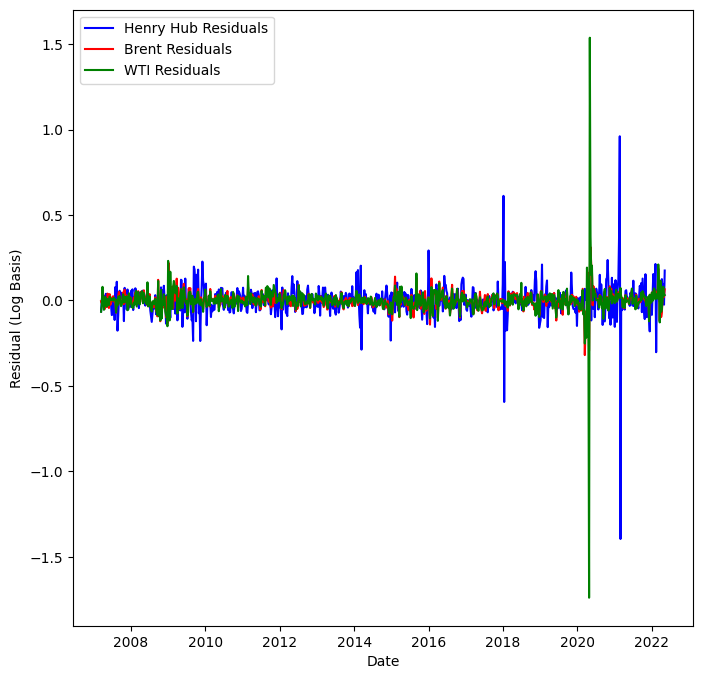

In [80]:
plt.figure(figsize=(8,8))
plt.plot(henry_resid, "b", label = 'Henry Hub Residuals')
plt.plot(brent_resid, "r", label = 'Brent Residuals')
plt.plot(wti_resid, "g", label = "WTI Residuals")

plt.xlabel(xlabel= "Date")
plt.ylabel(ylabel = "Residual (Log Basis)")
plt.legend(loc="upper left")

### Evaluating Autocorrelation with the Ljung-Box Test

In [96]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_wti = acorr_ljungbox(wti_resid, lags =[10,20], return_df = True)
lb_brent = acorr_ljungbox(brent_resid, lags=[10,20], return_df = True)
lb_henry = acorr_ljungbox(henry_resid, lags= [10,20], return_df = True)

print(f"WTI {lb_wti}")
print(f"Brent{lb_brent}")
print(f"Henry {lb_henry}")

WTI       lb_stat     lb_pvalue
10  57.166940  1.240074e-08
20  59.342116  8.998857e-06
Brent      lb_stat     lb_pvalue
10  47.561027  7.463512e-07
20  55.449293  3.517046e-05
Henry       lb_stat  lb_pvalue
10  29.859399   0.000903
20  45.096847   0.001071
